In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.ardl import ARDL
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#                           Data
data = pd.read_csv('data_ardl.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values(by='Date', ascending=True)
data = data.set_index('Date')
data.dropna(inplace=True)

exog = data.drop('US T-Note 10Y Yield', axis=1) # Exogenous data
endog = data['US T-Note 10Y Yield'] # Endogenous data is 10Y U.S. T-Note

print('\t Data Head :', '\n', data.head(), '\n')
print('Data Shape :', data.shape)

	 Data Head : 
             US T-Note 10Y Yield  USD/EUR  US Unemployment  US GDP  XAU/USD  \
Date                                                                         
1990-08-01                0.580    0.032              0.0   6.714    12.25   
1990-09-01               -0.557    0.000              0.1   6.714    20.15   
1990-10-01               -0.134   -0.020             -0.2 -91.865   -22.95   
1990-11-01               -0.188    0.020              0.2 -91.865     2.05   
1990-12-01                0.194    0.003             -0.2 -91.865    10.75   

            USD Index  OIL WTI   VIX  Interest Rates  US T-Bond 30Y Yield  \
Date                                                                        
1990-08-01      -0.58     6.63  8.79           -0.02                -5.53   
1990-09-01      -0.33    12.19 -0.79            0.07                 0.22   
1990-10-01      -2.96    -4.28  0.93           -0.09                 1.71   
1990-11-01      -0.51    -6.38 -7.88           -0.30

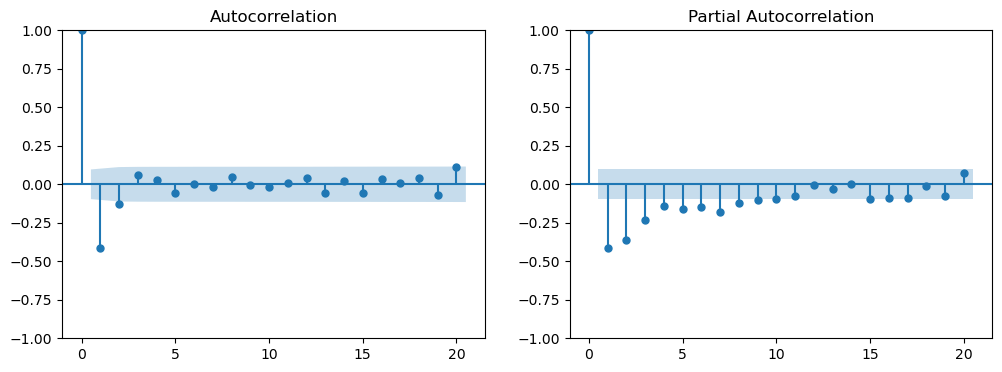

In [ ]:
#                      AutoCorrelation, Partial Autocorrelation of Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(data['US T-Note 10Y Yield'], ax=axes[0], lags=20)
plot_pacf(data['US T-Note 10Y Yield'], ax=axes[1], lags=20, method='ywm') # 'ywm' or 'ols'
plt.show()

In [4]:
#                 Augmented Dickey-Fuller Test
print('\t Augmented Dickey-Fuller Test :', '\n',)
for feature in data.columns :
    result = adfuller(data[feature].dropna(axis=0))
    print(f'- {feature} :', "Stationary" if result[1] <= 0.05 else "Non-Stationary") # Reject or not null hypothesis H0
    print(f'ADF Statistic: {round(result[0], 3)}, p-value: {round(result[1], 3)} \n')

	 Augmented Dickey-Fuller Test : 

- US T-Note 10Y Yield : Stationary
ADF Statistic: -8.69, p-value: 0.0 

- USD/EUR : Stationary
ADF Statistic: -8.72, p-value: 0.0 

- US Unemployment : Stationary
ADF Statistic: -8.201, p-value: 0.0 

- US GDP : Stationary
ADF Statistic: -4.627, p-value: 0.0 

- XAU/USD : Stationary
ADF Statistic: -3.803, p-value: 0.003 

- USD Index : Stationary
ADF Statistic: -18.773, p-value: 0.0 

- OIL WTI : Stationary
ADF Statistic: -16.624, p-value: 0.0 

- VIX : Stationary
ADF Statistic: -9.623, p-value: 0.0 

- Interest Rates : Stationary
ADF Statistic: -4.486, p-value: 0.0 

- US T-Bond 30Y Yield : Stationary
ADF Statistic: -15.285, p-value: 0.0 

- US T-Note 5Y Yield : Stationary
ADF Statistic: -18.283, p-value: 0.0 

- US T-Note 2Y Yield : Stationary
ADF Statistic: -4.874, p-value: 0.0 



In [5]:
#                       Train, Test Split
split_point = int(len(endog) * 0.75) # 75% Train, 25% Test
exog_train, exog_test = exog[:split_point], exog[split_point:]
endog_train, endog_test = endog[:split_point], endog[split_point:]

n, p = exog_test.shape[0], exog_test.shape[1] # NB of samples and features in test set (Useful for R2 Adjusted)

In [7]:
#                           ARDL
# Model
ARDL_model = ARDL(endog=endog_train, lags=2, exog=exog_train, order=1, causal=True, trend='c')
results = ARDL_model.fit()
forecast = results.predict(start=endog_test.index[0], end=endog_test.index[-1], exog_oos=exog_test)

# Metrics
ARDL_MSE = mean_squared_error(endog_test, forecast)
ARDL_R2 = r2_score(endog_test, forecast)
ARDL_R2_ADJ = 1 - (((1 - ARDL_R2) * (n - 1)) / (n - p - 1))

print('\tARDL Forecasting Metrics :', '\n', f'\nMSE = {round(ARDL_MSE,3)} \nR2 = {round(ARDL_R2,3)} \nAdjusted R2 = {round(ARDL_R2_ADJ,3)}\n')

print(results.summary())

	ARDL Forecasting Metrics : 
 
MSE = 0.084 
R2 = 0.32 
Adjusted R2 = 0.239

                                         ARDL Model Results                                         
Dep. Variable:                          US T-Note 10Y Yield   No. Observations:                  309
Model:             ARDL(2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)   Log Likelihood                 -43.483
Method:                                     Conditional MLE   S.D. of innovations              0.279
Date:                                      Fri, 19 Dec 2025   AIC                            116.966
Time:                                              22:46:59   BIC                            172.869
Sample:                                          10-01-1990   HQIC                           139.321
                                               - 04-01-2016                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

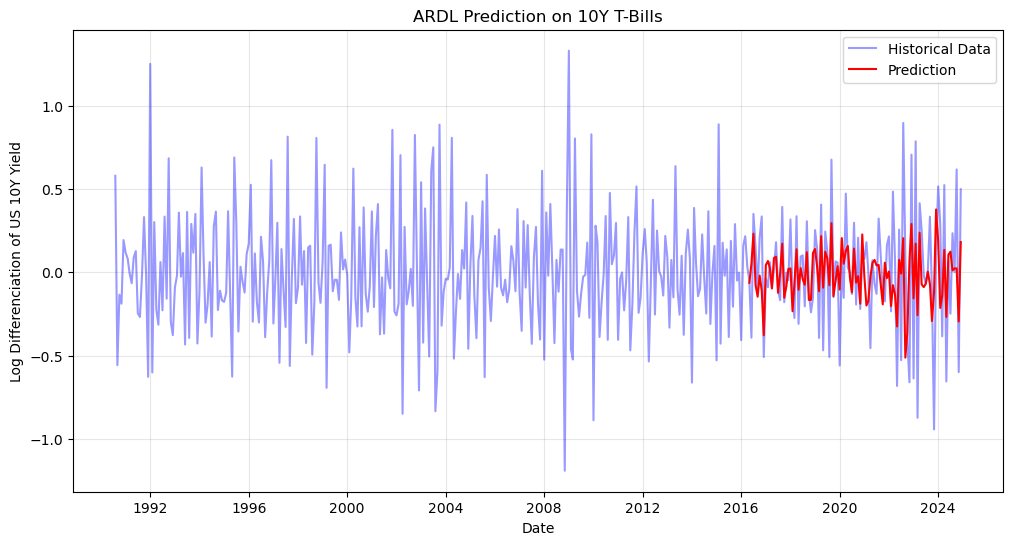

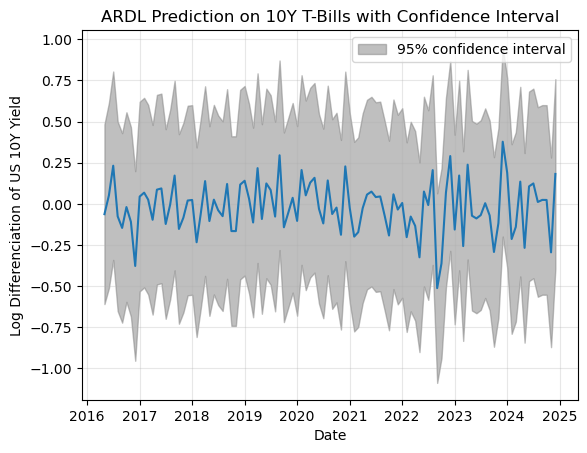

In [8]:
# Plot alongside historical data
plt.figure(figsize=(12,6))
plt.plot(data.index, data['US T-Note 10Y Yield'], label='Historical Data', color='blue', alpha=0.4)
plt.plot(forecast.index, forecast, label='Prediction', color='red', alpha=1)
plt.title('ARDL Prediction on 10Y T-Bills'); plt.xlabel('Date'); plt.ylabel('Log Differenciation of US 10Y Yield'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Plot with 95% confidence intervals
results.plot_predict(start=forecast.index[0], end=forecast.index[-1], dynamic=False, exog_oos=exog_test,)
plt.title('ARDL Prediction on 10Y T-Bills with Confidence Interval'); plt.xlabel('Date'); plt.ylabel('Log Differenciation of US 10Y Yield'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [10]:
#               Diagnostic Check
print(results.diagnostic_summary())

             Test of Normality              
Jarque-Bera    P-value   Skewness   Kurtosis
--------------------------------------------
     20.904      0.000      0.505      3.783


    Test of Conditional Homoskedasticity   
       Lag    ARCH-LM    P-value         DF
-------------------------------------------
         1      2.005      0.157          1
         2      5.241      0.073          2
         3      5.848      0.119          3
         4      5.897      0.207          4
         5      6.721      0.242          5
         6      9.034      0.172          6
         7     12.520      0.085          7
         8     12.404      0.134          8
         9     18.269      0.032          9
        10     18.488      0.047         10
-------------------------------------------
